## Lab 6: Decision Trees

In this lab you'll build and tune a decision tree to predict **forest cover type** from wilderness cartographic data. This is multi-class classification problem used by the US Forest Service to map land cover without costly field surveys.

**Dataset:** UCI Forest Cover Type (id=31). 581,012 records from four wilderness areas in the Roosevelt National Forest, Colorado. Features include elevation, slope, hillshade, distance to water and roads, wilderness area, and soil type. Our response varaible, `Cover_Type`, includes 7 different forest types: Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz (encoded as integers from 1 to 7). More information on the data can be found [here](https://archive.ics.uci.edu/dataset/31/covertype).


### Step 1: Load and Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [2]:
forest = fetch_ucirepo(id=31)

df = pd.concat([forest.data.features, forest.data.targets], axis=1)

print(f"Full dataset shape: {df.shape}")
print()
print("Cover type distribution (full dataset):")
print(df['Cover_Type'].value_counts().sort_index())
df.head()

Full dataset shape: (581012, 55)

Cover type distribution (full dataset):
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


### Step 2: Preprocess

The Forest Cover Type dataset is already clean and fully numeric, meaning all features are encoded as integers. The 54 features include:

- **10 continuous:** elevation, aspect, slope, hillshade indices, distances to hydrology, roadways, and fire points
- **44 binary:** 4 wilderness area indicators and 40 soil type indicators

No encoding or scaling is needed. We will sample 30,000 rows to keep lab runtimes manageable.

In [3]:
df_sample = df.sample(n=30_000, random_state=42)

features = [c for c in df_sample.columns if c != 'Cover_Type']
X = df_sample[features]
y = df_sample['Cover_Type']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y, random_state=42)
print(f"Training samples: {len(X_train):,}  |  Test samples: {len(X_test):,}")

Training samples: 21,000  |  Test samples: 9,000


### Step 3: Fit a Decision Tree

To start, we willfit a decision tree without specifying any hyperparameters. 

In [5]:
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_full.predict(X_train))
test_acc  = accuracy_score(y_test,  dt_full.predict(X_test))

print(f"Untuned tree depth:  {dt_full.get_depth()}")
print(f"Training accuracy:         {train_acc:.3f}")
print(f"Test accuracy:             {test_acc:.3f}")

Untuned tree depth:  35
Training accuracy:         1.000
Test accuracy:             0.780


##### Uh oh! Look at the difference between our test accuracy and our training accuracy. It looks like our model is overfitting! Let's try tuning to prevent this. 

### Step 4: Tune `max_depth` with Cross-Validation

Rather than evaluating each depth on the held-out test set (which leaks information), we use **5-fold cross-validation** on the training data. We will first tune `max_depth`, a hyperparameter which limits how many levels a tree can grow. Perform cross fold validation iterating over a max depth from 1 to 20. 

Best max_depth (5-fold CV): 18  (CV accuracy: 0.771)
Best max_depth (5-fold CV): 18  (CV accuracy: 0.771)


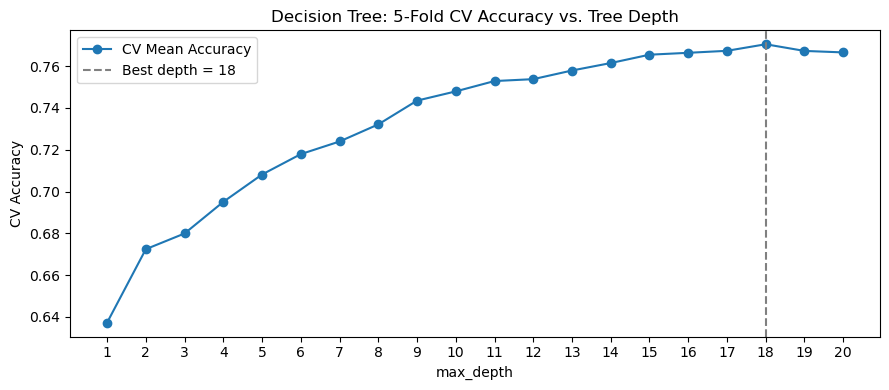

In [6]:
depths = range(1, 21)
cv_means =  []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())

cv_means = np.array(cv_means)
best_depth = list(depths)[np.argmax(cv_means)]
print(f"Best max_depth (5-fold CV): {best_depth}  (CV accuracy: {cv_means.max():.3f})")
print(f"Best max_depth (5-fold CV): {best_depth}  (CV accuracy: {cv_means.max():.3f})")

plt.figure(figsize=(9, 4))
plt.plot(list(depths), cv_means, label='CV Mean Accuracy', marker='o')
plt.axvline(best_depth, color='gray', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

### Step 5: Tune `min_samples_leaf` with Cross-Validation

`min_samples_leaf` sets the minimum number of training samples required at any leaf node. Perform cross fold validation iterating over the following numbers of minimum samples: 1, 5, 10, 25, 50, and 100. 

Best min_samples_leaf (5-fold CV): 1  (CV accuracy: 0.771)


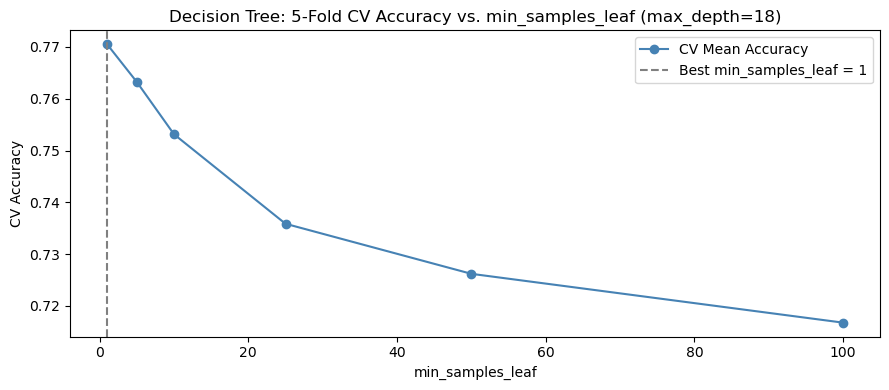

In [7]:
leaf_sizes = [1, 5, 10, 25, 50, 100]
leaf_cv_means = []

for n in leaf_sizes:
    dt = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=n, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    leaf_cv_means.append(scores.mean())


leaf_cv_means = np.array(leaf_cv_means)

best_leaf = leaf_sizes[np.argmax(leaf_cv_means)]


print(f"Best min_samples_leaf (5-fold CV): {best_leaf}  (CV accuracy: {leaf_cv_means.max():.3f})")

plt.figure(figsize=(9, 4))
plt.plot(leaf_sizes, leaf_cv_means, label='CV Mean Accuracy', marker='o', color='steelblue')
plt.axvline(best_leaf, color='gray', linestyle='--', label=f'Best min_samples_leaf = {best_leaf}')
plt.xlabel('min_samples_leaf')
plt.ylabel('CV Accuracy')
plt.title(f'Decision Tree: 5-Fold CV Accuracy vs. min_samples_leaf (max_depth={best_depth})')
plt.legend()
plt.tight_layout()
plt.show()

> **Discuss with a partner what it means to have a higher `min_samples_leaf` value.**

### Step 6: Joint Tuning with `GridSearchCV`

Tuning hyperparameters one at a time ignores their interactions. `GridSearchCV` evaluates every combination in a parameter grid using cross-validation, finding the jointly optimal settings. Use the `max_depth` values of 5, 10, 15, and 20, the `min_samples_leaf` values of 1,5, 10, and 25, and the `criterion` options of gini and entropy to find the best combination of paramters. 

In [9]:
param_grid = {
    'max_depth':        [5, 10, 15, 16, 17,18, 19, 20],
    'min_samples_leaf': [1, 5, 10, 25],
    'criterion':        ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters:  {grid_search.best_params_}")

dt_best = grid_search.best_estimator_
dt_acc  = accuracy_score(y_test, dt_best.predict(X_test))
print(f"Test accuracy:    {dt_acc:.3f}")

Best parameters:  {'criterion': 'gini', 'max_depth': 18, 'min_samples_leaf': 1}
Test accuracy:    0.776


**Discussion Questions**

> Does the best `max_depth` and `min_samples_leaf` from GridSearchCV match what you found by tuning it individually in Step 4? If not, why might joint tuning arrive at a different answer?


### Step 7: Visualize the Best Tree

Create a visualization of your decision tree with a `max_depth` of 3 (for plotting purposes), and the values that your grid search found to be best for `min_samples_leaf` and `criterion`. 

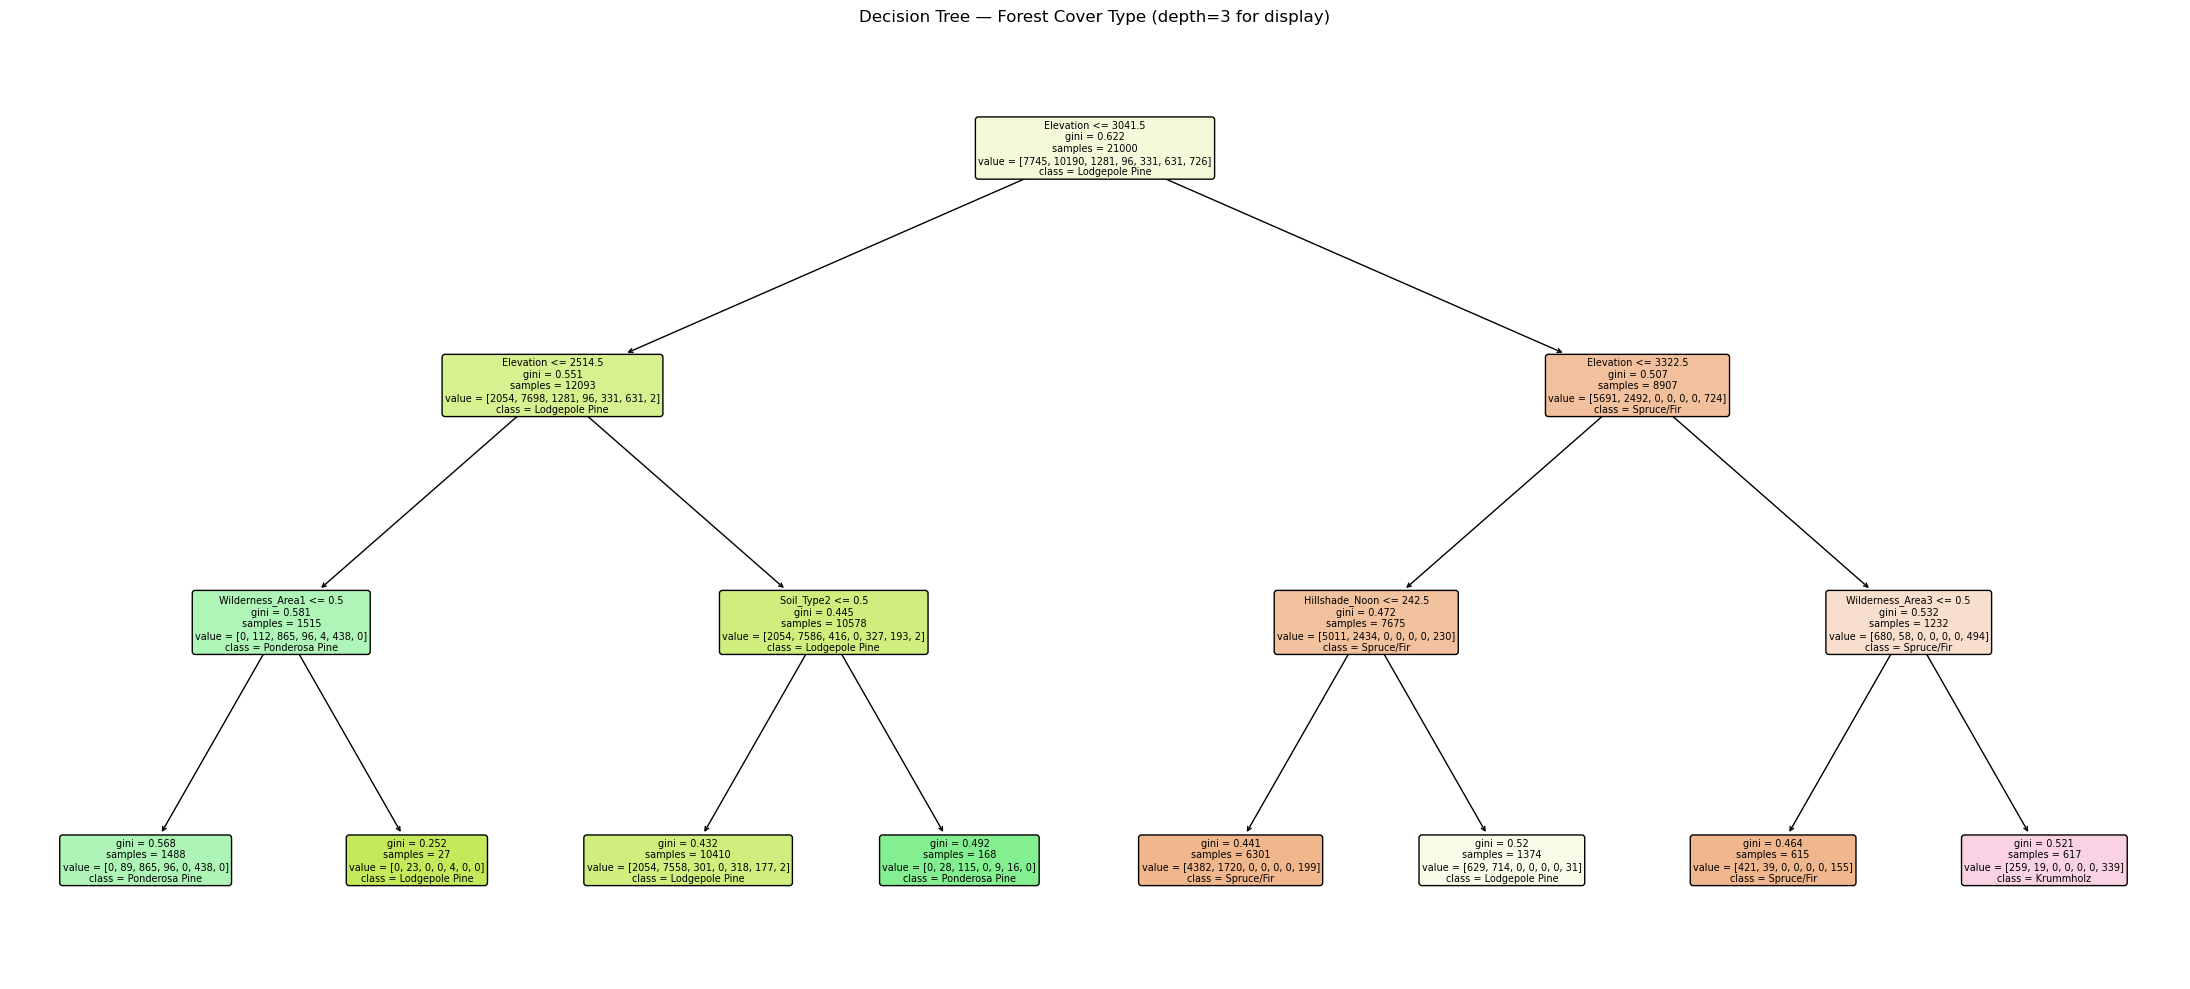

In [11]:
dt_viz = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    criterion=grid_search.best_params_['criterion'],
    random_state=42
)
dt_viz.fit(X_train, y_train)


plt.figure(figsize=(22, 10))
class_names = ['Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
               'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz']
               
# Plot tree
plot_tree(dt_viz, feature_names=features, class_names=class_names,
          filled=True, rounded=True, fontsize=7)
                         
plt.title('Decision Tree — Forest Cover Type (depth=3 for display)')
plt.tight_layout()
plt.show()

Discussion Questions: 

1. What feature appears at the root node (the very first split)? Does it make ecological sense that this feature is the most informative for separating forest cover types?
2. Look at the elevation threshold used at the root split (in meters). Rocky Mountain subalpine forests typically begin around 2,750–3,000m. Does the split value align with a meaningful ecological boundary?
3. Look at the observation below. What Forest Cover type would this observation be classified as with our tree above? 

In [13]:
df.iloc[2067][['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology','Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Cover_Type']]

Elevation                             2006
Aspect                                  53
Slope                                   12
Horizontal_Distance_To_Hydrology         0
Vertical_Distance_To_Hydrology           0
Horizontal_Distance_To_Roadways        255
Horizontal_Distance_To_Roadways        255
Hillshade_9am                          227
Hillshade_Noon                         215
Hillshade_3pm                          120
Horizontal_Distance_To_Fire_Points     366
Wilderness_Area1                         0
Cover_Type                               4
Name: 2067, dtype: int64

| # | Cover Type |
|---|------------|
| 1 | Spruce/Fir |
| 2 | Lodgepole Pine |
| 3 | Ponderosa Pine |
| 4 | Cottonwood/Willow |
| 5 | Aspen |
| 6 | Douglas-fir |
| 7 | Krummholz |

### Step 8: Feature Importance

With 54 features, many soil type indicators will have very little importance. Create a plot showing the top 15 most important features.

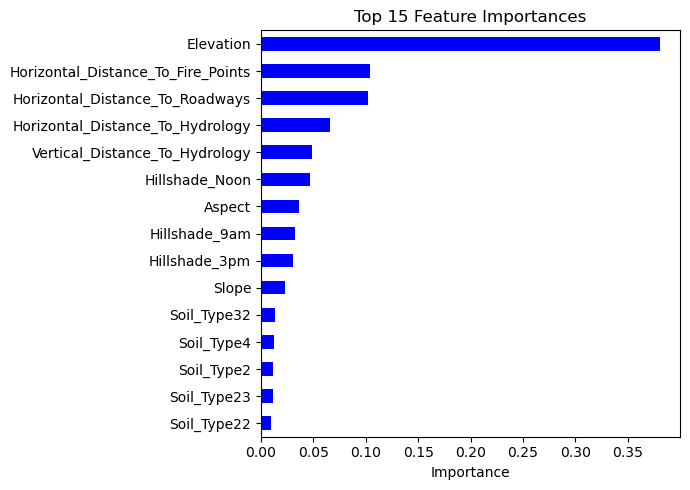

In [12]:
feat_imp = pd.Series(dt_best.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
feat_imp.head(15).sort_values().plot(kind='barh', color='blue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

> Which feature is most important? Is this the same feature that appeared at the root node of the tree in Step 7?
